# Normalisation

In [1]:
# load packages
suppressPackageStartupMessages({
    library(Matrix)
    library(scran)
    library(scater)
    library(igraph)
    library(BiocParallel)
})
ncores = 16
mcparam = SnowParam(workers = ncores)
register(mcparam)

main = "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/"
dir.create(paste0(main, '04_normalisation/'), showWarnings = FALSE)

source(paste0(main, "mapping_functions_extended.R"))
load_data(normalise = FALSE)


lib.sizes = Matrix::colSums(counts(sce))
sce = sce[calculateAverage(sce)>0.1,]

In [3]:
clusts = as.numeric(quickCluster(sce, method = "igraph", min.size = 100, BPPARAM = mcparam))

In [4]:
#now run the normalisation
#number of cells in each cluster should be at least twice that of the largest 'sizes'
min.clust = min(table(clusts))/2
new_sizes = c(floor(min.clust/3), floor(min.clust/2), floor(min.clust))
sce = computeSumFactors(sce, clusters = clusts, sizes = new_sizes, max.cluster.size = 3000)


p1 = ggplot(data = data.frame(X = lib.sizes, Y = sizeFactors(sce)),
              mapping = aes(x = X, y = Y)) +
  geom_point() +
  scale_x_log10(breaks = c(5000, 10000, 50000, 100000), labels = c("5,000", "10,000", "50,000", "100,000") ) +
  scale_y_log10(breaks = c(0.2, 1, 5)) +
  labs(x = "Number of UMIs", y = "Size Factor") +
  theme_bw() + 
  theme(text = element_text(size=20)) 

Saving 6.67 x 6.67 in image



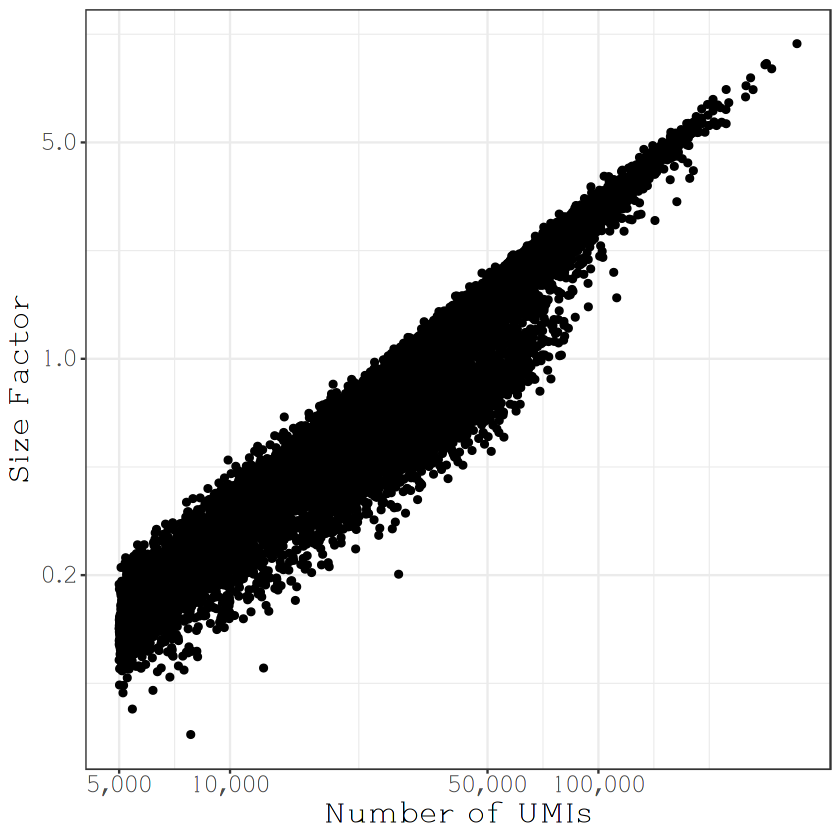

In [5]:
p1
ggsave(paste0(main, '04_normalisation/size_factors.png'), p1, device='png')

In [6]:
write.table(sizeFactors(sce), quote = F, col.names = F, row.names = F, file = paste0(main, "04_normalisation/sizefactors.tab"))

In [7]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Manjaro Linux

Matrix products: default
BLAS:   /usr/local/lib64/R/lib/libRblas.so
LAPACK: /usr/local/lib64/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_GB.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=en_GB.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=en_GB.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_GB.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] parallel  stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] BiocParallel_1.24.1         igraph_1.2.6               
 [3] scater_1.18.3               ggplot2_3.3.5              
 [5] scran_1.18.1                SingleCellExperiment_1.12.0
 [7] SummarizedExperiment_1.20.0 Biobase_2.50.0             
 [9] GenomicRanges_1.42.0        